# Dataset 3: Early Autism Screening — Model Training & Evaluation

**Project:** Multi-Modal Autism Spectrum Disorder (ASD) Detection  
**Dataset:** Q-CHAT-10 Behavioral Screening for Toddlers  
**Objective:** Train and compare multiple ML/DL classifiers to predict ASD traits from screening questionnaire responses and demographics, targeting **F1-score ≥ 90%**.

---

### Models Implemented
| # | Model | Type |
|---|-------|------|
| 1 | Random Forest | Ensemble (Bagging) |
| 2 | XGBoost | Gradient Boosting |
| 3 | LightGBM | Gradient Boosting |
| 4 | Support Vector Machine | Kernel-based |
| 5 | KAN (Kolmogorov-Arnold Network) | Deep Learning |

---

## 1. Imports & Setup

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)

import xgboost as xgb
import lightgbm as lgb
import shap

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("[OK] All libraries loaded successfully")
print(f"  PyTorch: {torch.__version__}")
print(f"  XGBoost: {xgb.__version__}")
print(f"  LightGBM: {lgb.__version__}")

[OK] All libraries loaded successfully
  PyTorch: 2.14.0+cpu
  XGBoost: 3.4.1
  LightGBM: 4.7.0


## 2. Data Loading

The **Q-CHAT-10 (Quantitative Checklist for Autism in Toddlers)** dataset contains 1,054 screening records for toddlers aged 12–36 months. Each record includes:
- **A1–A10**: 10 binary screening items measuring social communication, joint attention, gaze response, pretend play, and repetitive behavior
- **Demographics**: Age, Sex, Ethnicity, Jaundice history, Family ASD history
- **Target**: `Class/ASD Traits` — Whether the toddler screens positive for ASD traits (Yes/No)

In [2]:
# Load the toddler screening dataset with multi-location fallback
candidates = [
    os.path.abspath(os.path.join('..', 'Datasets', '3rd Dataset_Early Autism Screening Dataset for Toddlers')),
    os.path.abspath(os.path.join('..', '..', 'Datasets', '3rd Dataset_Early Autism Screening Dataset for Toddlers')),
    os.path.abspath(os.path.join('Datasets', '3rd Dataset_Early Autism Screening Dataset for Toddlers')),
    r'd:\College\7thSemProject\Datasets\3rd Dataset_Early Autism Screening Dataset for Toddlers'
]
DATA_DIR = next((p for p in candidates if os.path.exists(os.path.join(p, 'Toddler Autism dataset July 2018.csv'))), candidates[0])

csv_path = os.path.join(DATA_DIR, 'Toddler Autism dataset July 2018.csv')
df_raw = pd.read_csv(csv_path)
df_raw.columns = df_raw.columns.str.strip()  # Fix trailing whitespace in column names

print(f"Resolved data directory: {DATA_DIR}")
print(f"Dataset shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}\n")
df_raw.head(10)


Resolved data directory: d:\College\7thSemProject\Datasets\3rd Dataset_Early Autism Screening Dataset for Toddlers
Dataset shape: (1054, 19)
Columns: ['Case_No', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age_Mons', 'Qchat-10-Score', 'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD', 'Who completed the test', 'Class/ASD Traits']



,Case_No,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat-10-Score,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who completed the test,Class/ASD Traits
0,1,0,0,0,0,0,0,1,1,0,1,28,3,f,middle eastern,yes,no,family member,No
1,2,1,1,0,0,0,1,1,0,0,0,36,4,m,White European,yes,no,family member,Yes
2,3,1,0,0,0,0,0,1,1,0,1,36,4,m,middle eastern,yes,no,family member,Yes
3,4,1,1,1,1,1,1,1,1,1,1,24,10,m,Hispanic,no,no,family member,Yes
4,5,1,1,0,1,1,1,1,1,1,1,20,9,f,White European,no,yes,family member,Yes
5,6,1,1,0,0,1,1,1,1,1,1,21,8,m,black,no,no,family member,Yes
6,7,1,0,0,1,1,1,0,0,1,0,33,5,m,asian,yes,no,family member,Yes
7,8,0,1,0,0,1,0,1,1,1,1,33,6,m,asian,yes,no,family member,Yes
8,9,0,0,0,0,0,0,1,0,0,1,36,2,m,asian,no,no,family member,No
9,10,1,1,1,0,1,1,0,1,1,1,22,8,m,south asian,no,no,Health Care Professional,Yes


In [3]:
# Basic info
print("=" * 60)
print("DATASET INFO")
print("=" * 60)
print(f"Total samples: {len(df_raw)}")
print(f"Features: {df_raw.shape[1]} columns")
print()
print(df_raw.dtypes)
print()
print("Missing values:")
print(df_raw.isnull().sum())

DATASET INFO
Total samples: 1054
Features: 19 columns

Case_No                   int64
A1                        int64
A2                        int64
A3                        int64
A4                        int64
A5                        int64
A6                        int64
A7                        int64
A8                        int64
A9                        int64
A10                       int64
Age_Mons                  int64
Qchat-10-Score            int64
Sex                         str
Ethnicity                   str
Jaundice                    str
Family_mem_with_ASD         str
Who completed the test      str
Class/ASD Traits            str
dtype: object

Missing values:
Case_No                   0
A1                        0
A2                        0
A3                        0
A4                        0
A5                        0
A6                        0
A7                        0
A8                        0
A9                        0
A10                       

## 3. Exploratory Data Analysis (EDA)

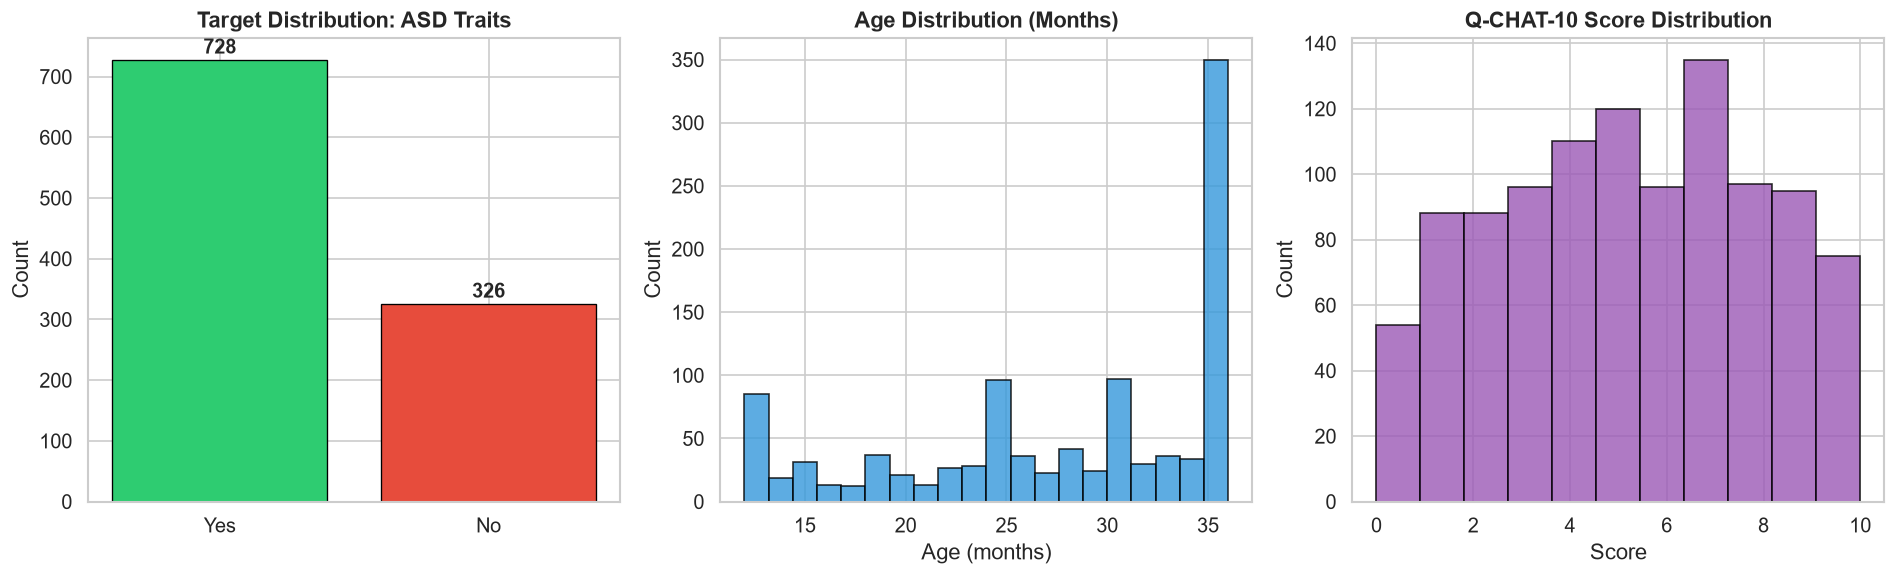


Class balance:
  ASD = Yes: 728 (69.1%)
  ASD = No:  326 (30.9%)


In [4]:
# Class distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Target distribution
class_counts = df_raw['Class/ASD Traits'].value_counts()
colors_target = ['#2ecc71', '#e74c3c']
axes[0].bar(class_counts.index, class_counts.values, color=colors_target, edgecolor='black', linewidth=0.8)
axes[0].set_title('Target Distribution: ASD Traits', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(zip(class_counts.index, class_counts.values)):
    axes[0].text(i, val + 10, str(val), ha='center', fontweight='bold', fontsize=12)

# 2. Age distribution
axes[1].hist(df_raw['Age_Mons'], bins=20, color='#3498db', edgecolor='black', alpha=0.8)
axes[1].set_title('Age Distribution (Months)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age (months)')
axes[1].set_ylabel('Count')

# 3. Q-CHAT Score distribution
axes[2].hist(df_raw['Qchat-10-Score'], bins=11, color='#9b59b6', edgecolor='black', alpha=0.8)
axes[2].set_title('Q-CHAT-10 Score Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Score')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"\nClass balance:")
print(f"  ASD = Yes: {(df_raw['Class/ASD Traits'] == 'Yes').sum()} ({(df_raw['Class/ASD Traits'] == 'Yes').mean()*100:.1f}%)")
print(f"  ASD = No:  {(df_raw['Class/ASD Traits'] == 'No').sum()} ({(df_raw['Class/ASD Traits'] == 'No').mean()*100:.1f}%)")

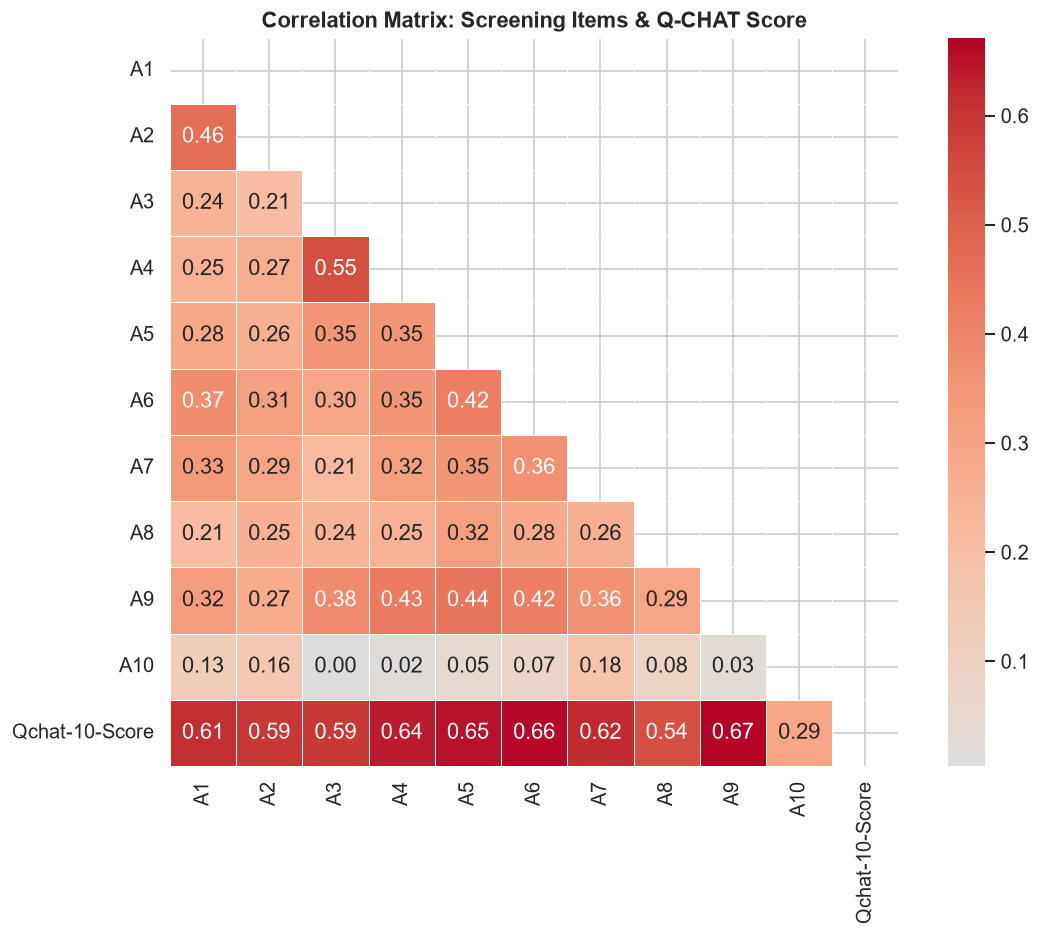

In [5]:
# Correlation heatmap for screening items
screening_items = ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10']
fig, ax = plt.subplots(figsize=(10, 8))
corr = df_raw[screening_items + ['Qchat-10-Score']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix: Screening Items & Q-CHAT Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

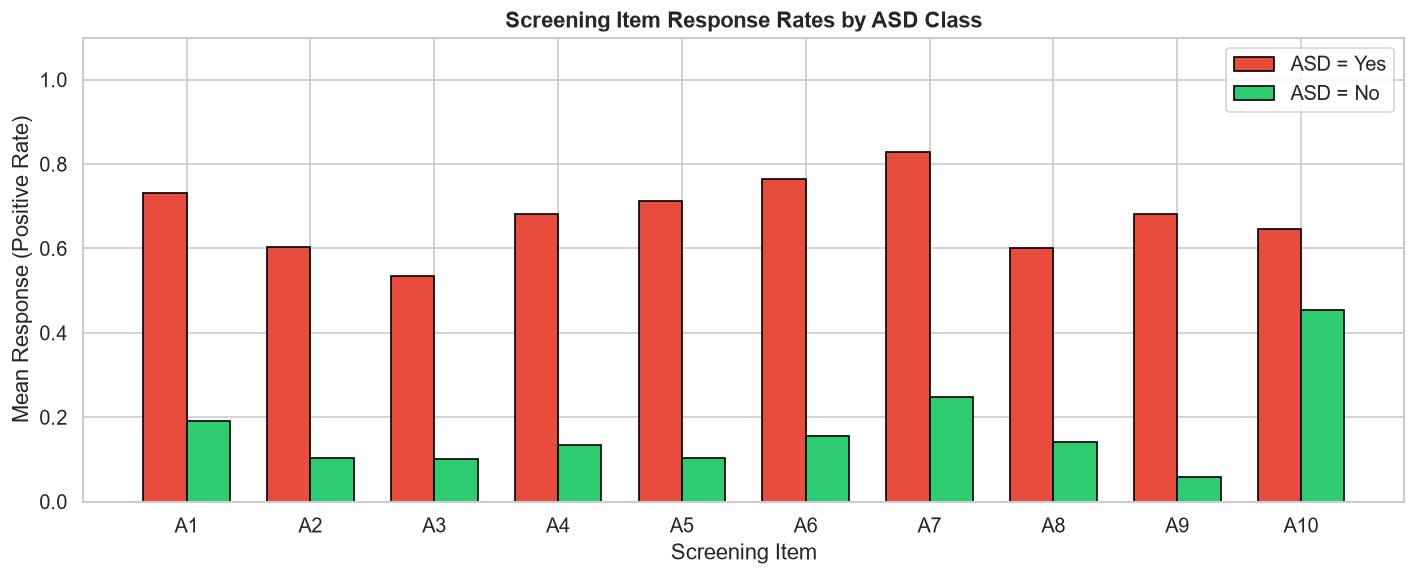

In [6]:
# Screening item response rates by ASD class
fig, ax = plt.subplots(figsize=(12, 5))
asd_yes = df_raw[df_raw['Class/ASD Traits'] == 'Yes'][screening_items].mean()
asd_no = df_raw[df_raw['Class/ASD Traits'] == 'No'][screening_items].mean()

x = np.arange(len(screening_items))
width = 0.35
bars1 = ax.bar(x - width/2, asd_yes, width, label='ASD = Yes', color='#e74c3c', edgecolor='black')
bars2 = ax.bar(x + width/2, asd_no, width, label='ASD = No', color='#2ecc71', edgecolor='black')

ax.set_xlabel('Screening Item')
ax.set_ylabel('Mean Response (Positive Rate)')
ax.set_title('Screening Item Response Rates by ASD Class', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(screening_items)
ax.legend()
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

### Preprocessing Steps:
1. Drop identifier column (`Case_No`) and derived score column (`Qchat-10-Score`)
2. Encode binary categorical features (`Sex`, `Jaundice`, `Family_mem_with_ASD`)
3. Label-encode multi-class categoricals (`Ethnicity`, `Who completed the test`)
4. Encode binary target (`Class/ASD Traits` → 1/0)
5. Stratified train/validation/test split (70/15/15)
6. StandardScaler fitted **only** on training data (no leakage)

> **Note:** We drop `Qchat-10-Score` because it is a direct deterministic function of A1–A10 (their sum), and the target `Class/ASD Traits` is directly derived from this score (threshold ≥ 4). Including it would cause trivial data leakage. Instead, we let the models learn from the **individual screening items** and demographics.

In [7]:
# Preprocessing
df = df_raw.copy()

# Drop ID and derived score
df = df.drop(columns=['Case_No', 'Qchat-10-Score'])

# Encode target
df['Class/ASD Traits'] = df['Class/ASD Traits'].map({'Yes': 1, 'No': 0})

# Encode binary categoricals
df['Sex'] = df['Sex'].map({'m': 1, 'f': 0})
df['Jaundice'] = df['Jaundice'].map({'yes': 1, 'no': 0})
df['Family_mem_with_ASD'] = df['Family_mem_with_ASD'].map({'yes': 1, 'no': 0})

# Encode multi-class categoricals
le_ethnicity = LabelEncoder()
df['Ethnicity'] = le_ethnicity.fit_transform(df['Ethnicity'].astype(str))

le_who = LabelEncoder()
df['Who completed the test'] = le_who.fit_transform(df['Who completed the test'].astype(str))

# Define feature columns and target
target_col = 'Class/ASD Traits'
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols].values.astype(np.float32)
y = df[target_col].values.astype(np.int32)

print(f"Feature matrix shape: {X.shape}")
print(f"Features: {feature_cols}")
print(f"Target distribution: Positive={y.sum()}, Negative={(1-y).sum()}")

Feature matrix shape: (1054, 16)
Features: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age_Mons', 'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD', 'Who completed the test']
Target distribution: Positive=728, Negative=326


In [8]:
# Stratified Train / Validation / Test Split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.176, random_state=SEED, stratify=y_trainval  # 0.176 ≈ 0.15/0.85
)

# Scale numerical features (fitted on train only)
scaler = StandardScaler()
num_idx = [feature_cols.index(c) for c in ['Age_Mons'] if c in feature_cols]

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

if num_idx:
    X_train_scaled[:, num_idx] = scaler.fit_transform(X_train[:, num_idx])
    X_val_scaled[:, num_idx] = scaler.transform(X_val[:, num_idx])
    X_test_scaled[:, num_idx] = scaler.transform(X_test[:, num_idx])

print(f"Train: {X_train.shape[0]} samples (Pos: {y_train.sum()}, Neg: {(1-y_train).sum()})")
print(f"Val:   {X_val.shape[0]} samples (Pos: {y_val.sum()}, Neg: {(1-y_val).sum()})")
print(f"Test:  {X_test.shape[0]} samples (Pos: {y_test.sum()}, Neg: {(1-y_test).sum()})")

Train: 737 samples (Pos: 509, Neg: 228)
Val:   158 samples (Pos: 109, Neg: 49)
Test:  159 samples (Pos: 110, Neg: 49)


In [9]:
# --- Evaluation Helper ---------------------------------------------
results_log = []  # Collect all model results for final comparison

def evaluate_model(model_name, y_true, y_pred, y_prob=None):
    """Compute and display all metrics for a model."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob) if y_prob is not None else 0.0

    print(f"\n{'='*55}")
    print(f"  {model_name} -- Test Set Results")
    print(f"{'='*55}")
    print(f"  Accuracy:  {acc:.4f}  ({acc*100:.1f}%)")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}  [PASS]" if f1 >= 0.90 else f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {auc:.4f}")
    print(f"{'='*55}")
    print()
    print(classification_report(y_true, y_pred, target_names=['Non-ASD (0)', 'ASD (1)'], digits=4))

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Non-ASD', 'ASD']).plot(
        ax=ax, cmap='Blues', values_format='d'
    )
    ax.set_title(f'{model_name} -- Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()

    results_log.append({
        'Model': model_name, 'Accuracy': round(acc, 4),
        'Precision': round(prec, 4), 'Recall': round(rec, 4),
        'F1-Score': round(f1, 4), 'ROC-AUC': round(auc, 4),
        'y_prob': y_prob, 'y_pred': y_pred
    })
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': auc}

## 5. Model 1: Random Forest

Random Forest is an ensemble of decision trees using bagging. It's robust to overfitting and handles both numerical and categorical features well. We use `RandomizedSearchCV` for hyperparameter tuning with 5-fold stratified cross-validation.

Best RF params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': None}
Best CV F1: 0.9690

  Random Forest -- Test Set Results
  Accuracy:  0.9748  (97.5%)
  Precision: 0.9907
  Recall:    0.9727
  F1-Score:  0.9817  [PASS]
  ROC-AUC:   0.9981

              precision    recall  f1-score   support

 Non-ASD (0)     0.9412    0.9796    0.9600        49
     ASD (1)     0.9907    0.9727    0.9817       110

    accuracy                         0.9748       159
   macro avg     0.9660    0.9762    0.9708       159
weighted avg     0.9755    0.9748    0.9750       159



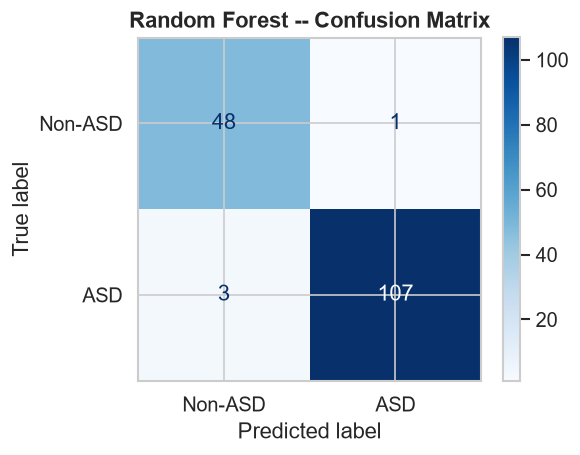

In [10]:
# Random Forest with Hyperparameter Tuning
rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', None]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED),
    rf_params, n_iter=15, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='f1', random_state=SEED, n_jobs=2, verbose=0
)
rf_search.fit(X_train_scaled, y_train)

rf_best = rf_search.best_estimator_
print(f"Best RF params: {rf_search.best_params_}")
print(f"Best CV F1: {rf_search.best_score_:.4f}")

# Evaluate on test set
rf_pred = rf_best.predict(X_test_scaled)
rf_prob = rf_best.predict_proba(X_test_scaled)[:, 1]
rf_metrics = evaluate_model("Random Forest", y_test, rf_pred, rf_prob)

## 6. Model 2: XGBoost

XGBoost (Extreme Gradient Boosting) is a state-of-the-art gradient boosting framework. It uses regularized boosting to prevent overfitting and supports GPU acceleration.

Best XGB params: {'subsample': 1.0, 'scale_pos_weight': 1, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 1.0}
Best CV F1: 0.9900

  XGBoost -- Test Set Results
  Accuracy:  0.9937  (99.4%)
  Precision: 1.0000
  Recall:    0.9909
  F1-Score:  0.9954  [PASS]
  ROC-AUC:   1.0000

              precision    recall  f1-score   support

 Non-ASD (0)     0.9800    1.0000    0.9899        49
     ASD (1)     1.0000    0.9909    0.9954       110

    accuracy                         0.9937       159
   macro avg     0.9900    0.9955    0.9927       159
weighted avg     0.9938    0.9937    0.9937       159



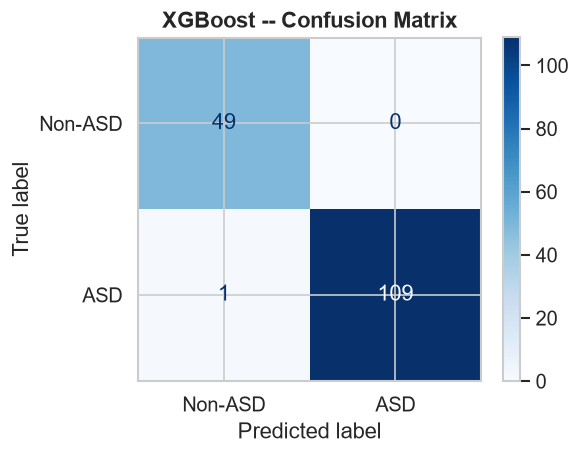

In [11]:
# XGBoost with Hyperparameter Tuning
xgb_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2],
    'scale_pos_weight': [1, (1 - y_train.mean()) / y_train.mean()]
}

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(
        objective='binary:logistic', eval_metric='logloss',
        use_label_encoder=False, random_state=SEED, verbosity=0
    ),
    xgb_params, n_iter=15, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='f1', random_state=SEED, n_jobs=2, verbose=0
)
xgb_search.fit(X_train_scaled, y_train)

xgb_best = xgb_search.best_estimator_
print(f"Best XGB params: {xgb_search.best_params_}")
print(f"Best CV F1: {xgb_search.best_score_:.4f}")

# Evaluate on test set
xgb_pred = xgb_best.predict(X_test_scaled)
xgb_prob = xgb_best.predict_proba(X_test_scaled)[:, 1]
xgb_metrics = evaluate_model("XGBoost", y_test, xgb_pred, xgb_prob)

## 7. Model 3: LightGBM

LightGBM is a high-performance gradient boosting framework that uses histogram-based learning and leaf-wise tree growth. It's faster than XGBoost on large datasets while maintaining comparable accuracy.

Best LGB params: {'subsample': 0.7, 'reg_lambda': 0.01, 'reg_alpha': 0.1, 'num_leaves': 63, 'n_estimators': 500, 'min_child_samples': 5, 'max_depth': 3, 'learning_rate': 0.1, 'is_unbalance': False, 'colsample_bytree': 1.0}
Best CV F1: 0.9851

  LightGBM -- Test Set Results
  Accuracy:  0.9874  (98.7%)
  Precision: 0.9909
  Recall:    0.9909
  F1-Score:  0.9909  [PASS]
  ROC-AUC:   0.9998

              precision    recall  f1-score   support

 Non-ASD (0)     0.9796    0.9796    0.9796        49
     ASD (1)     0.9909    0.9909    0.9909       110

    accuracy                         0.9874       159
   macro avg     0.9853    0.9853    0.9853       159
weighted avg     0.9874    0.9874    0.9874       159



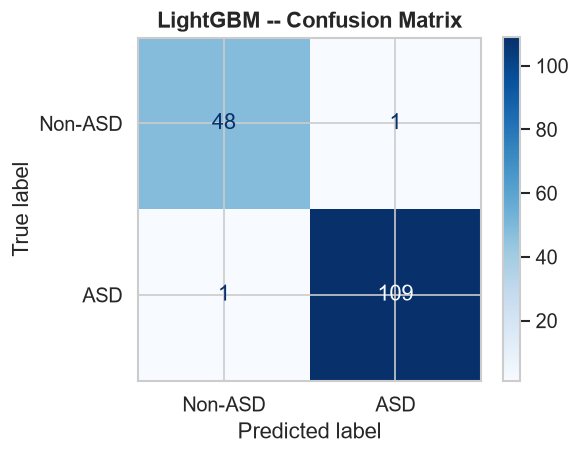

In [12]:
# LightGBM with Hyperparameter Tuning
lgb_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [15, 31, 63, 127],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_samples': [5, 10, 20],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [0, 0.01, 0.1],
    'is_unbalance': [True, False]
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=SEED, verbose=-1),
    lgb_params, n_iter=15, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='f1', random_state=SEED, n_jobs=2, verbose=0
)
lgb_search.fit(X_train_scaled, y_train)

lgb_best = lgb_search.best_estimator_
print(f"Best LGB params: {lgb_search.best_params_}")
print(f"Best CV F1: {lgb_search.best_score_:.4f}")

# Evaluate on test set
lgb_pred = lgb_best.predict(X_test_scaled)
lgb_prob = lgb_best.predict_proba(X_test_scaled)[:, 1]
lgb_metrics = evaluate_model("LightGBM", y_test, lgb_pred, lgb_prob)

## 8. Model 4: Support Vector Machine (SVM)

SVM with RBF kernel finds the optimal hyperplane that maximizes the margin between classes. It works well on medium-sized datasets with clear class boundaries.

Best SVM params: {'kernel': 'rbf', 'gamma': 0.01, 'class_weight': 'balanced', 'C': 100}
Best CV F1: 1.0000

  SVM (RBF) -- Test Set Results
  Accuracy:  1.0000  (100.0%)
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000  [PASS]
  ROC-AUC:   1.0000

              precision    recall  f1-score   support

 Non-ASD (0)     1.0000    1.0000    1.0000        49
     ASD (1)     1.0000    1.0000    1.0000       110

    accuracy                         1.0000       159
   macro avg     1.0000    1.0000    1.0000       159
weighted avg     1.0000    1.0000    1.0000       159



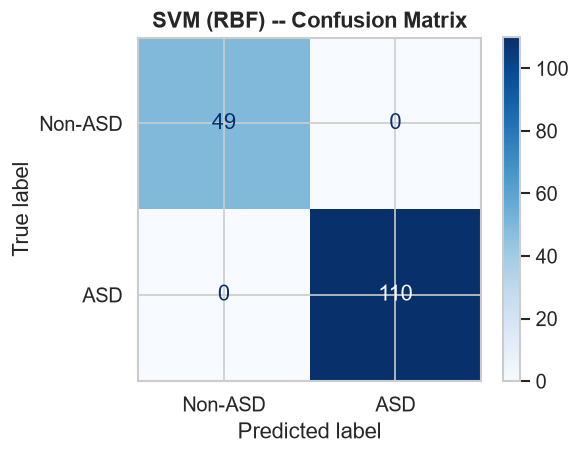

In [13]:
# SVM with Hyperparameter Tuning
svm_params = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'poly'],
    'class_weight': ['balanced', None]
}

svm_search = RandomizedSearchCV(
    SVC(probability=True, random_state=SEED),
    svm_params, n_iter=10, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='f1', random_state=SEED, n_jobs=2, verbose=0
)
svm_search.fit(X_train_scaled, y_train)

svm_best = svm_search.best_estimator_
print(f"Best SVM params: {svm_search.best_params_}")
print(f"Best CV F1: {svm_search.best_score_:.4f}")

# Evaluate on test set
svm_pred = svm_best.predict(X_test_scaled)
svm_prob = svm_best.predict_proba(X_test_scaled)[:, 1]
svm_metrics = evaluate_model("SVM (RBF)", y_test, svm_pred, svm_prob)

## 9. Model 5: KAN (Kolmogorov-Arnold Network)

The **Kolmogorov-Arnold Network (KAN)** replaces traditional linear weights with learnable **B-spline activation functions**, based on the Kolmogorov-Arnold representation theorem. This allows the network to learn complex non-linear transformations on each feature dimension independently.

### Architecture:
- **KANLinear layers**: Replace `y = W·x + b` with `y = Σ φ_i(x_i)` where each φ is a B-spline
- **LayerNorm + Dropout** between hidden layers
- **Sigmoid output** for binary classification

In [14]:
# --- KAN Model Definition ------------------------------------------
import math

class KANLinear(nn.Module):
    def __init__(self, in_features, out_features, grid_size=5, spline_order=3):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        h = 2.0 / grid_size
        grid = (torch.arange(-spline_order, grid_size + spline_order + 1) * h - 1.0).expand(in_features, -1).contiguous()
        self.register_buffer("grid", grid)
        self.spline_order = spline_order
        self.base_activation = nn.SiLU()
        self.base_weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.spline_weight = nn.Parameter(torch.Tensor(out_features, in_features, grid_size + spline_order))
        nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5))
        nn.init.normal_(self.spline_weight, mean=0.0, std=0.1 / grid_size)

    def b_splines(self, x):
        x = x.unsqueeze(-1)
        bases = ((x >= self.grid[:, :-1]) & (x < self.grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            left = (x - self.grid[:, :-(k+1)]) / (self.grid[:, k:-1] - self.grid[:, :-(k+1)])
            right = (self.grid[:, k+1:] - x) / (self.grid[:, k+1:] - self.grid[:, 1:-k])
            bases = torch.nan_to_num(left) * bases[:, :, :-1] + torch.nan_to_num(right) * bases[:, :, 1:]
        return bases.contiguous()

    def forward(self, x):
        base_out = torch.nn.functional.linear(self.base_activation(x), self.base_weight)
        spline_out = torch.einsum('oik,bik->bo', self.spline_weight, self.b_splines(x))
        return base_out + spline_out

class KAN(nn.Module):
    def __init__(self, input_dim, hidden_layers=[64, 32], grid_size=5, spline_order=3, dropout=0.15):
        super().__init__()
        dims = [input_dim] + hidden_layers + [1]
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.drops = nn.ModuleList()
        for i in range(len(dims) - 1):
            self.layers.append(KANLinear(dims[i], dims[i+1], grid_size, spline_order))
            if i < len(dims) - 2:
                self.norms.append(nn.LayerNorm(dims[i+1]))
                self.drops.append(nn.Dropout(dropout))

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.norms[i](x)
                x = self.drops[i](x)
        return torch.sigmoid(x).squeeze(-1)

print("[OK] KAN architecture defined")

[OK] KAN architecture defined


Training device: cpu
Epoch   1/100 | Train Loss: 0.5206 | Val Loss: 0.3372 | Val Acc: 0.9241
Epoch  10/100 | Train Loss: 0.0322 | Val Loss: 0.0678 | Val Acc: 0.9684
Epoch  20/100 | Train Loss: 0.0054 | Val Loss: 0.0107 | Val Acc: 1.0000
Epoch  30/100 | Train Loss: 0.0073 | Val Loss: 0.0197 | Val Acc: 0.9873
Epoch  40/100 | Train Loss: 0.0016 | Val Loss: 0.0012 | Val Acc: 1.0000
Epoch  50/100 | Train Loss: 0.0015 | Val Loss: 0.0025 | Val Acc: 1.0000
Epoch  60/100 | Train Loss: 0.0008 | Val Loss: 0.0007 | Val Acc: 1.0000
Epoch  70/100 | Train Loss: 0.0007 | Val Loss: 0.0007 | Val Acc: 1.0000
Epoch  80/100 | Train Loss: 0.0007 | Val Loss: 0.0006 | Val Acc: 1.0000
Epoch  90/100 | Train Loss: 0.0006 | Val Loss: 0.0008 | Val Acc: 1.0000
Early stopping at epoch 99

  KAN -- Test Set Results
  Accuracy:  1.0000  (100.0%)
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000  [PASS]
  ROC-AUC:   1.0000

              precision    recall  f1-score   support

 Non-ASD (0)     1.0000    1.00

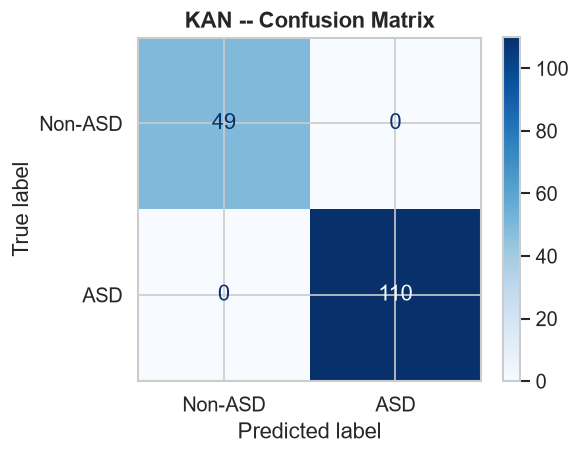

In [15]:
# --- Train KAN -----------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training device: {device}")

# Convert to tensors
X_tr_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_tr_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
X_te_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_te_t = torch.tensor(y_test, dtype=torch.float32)

train_ds = TensorDataset(X_tr_t, y_tr_t)
val_ds = TensorDataset(X_val_t, y_val_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

# Initialize model
kan_model = KAN(input_dim=X_train.shape[1], hidden_layers=[64, 32], grid_size=5, dropout=0.15).to(device)
criterion = nn.BCELoss()
optimizer = optim.AdamW(kan_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Training loop
EPOCHS = 100
best_val_loss = float('inf')
patience_counter = 0
patience = 15
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    # Train
    kan_model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = kan_model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(kan_model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item() * len(yb)
    train_loss /= len(train_ds)

    # Validate
    kan_model.eval()
    val_loss = 0
    val_correct = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = kan_model(xb)
            val_loss += criterion(pred, yb).item() * len(yb)
            val_correct += ((pred >= 0.5).float() == yb).sum().item()
    val_loss /= len(val_ds)
    val_acc = val_correct / len(val_ds)

    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in kan_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# Load best model and evaluate
kan_model.load_state_dict(best_state)
kan_model.eval()
with torch.no_grad():
    kan_prob = kan_model(X_te_t.to(device)).cpu().numpy()
kan_pred = (kan_prob >= 0.5).astype(int)

kan_metrics = evaluate_model("KAN", y_test, kan_pred, kan_prob)

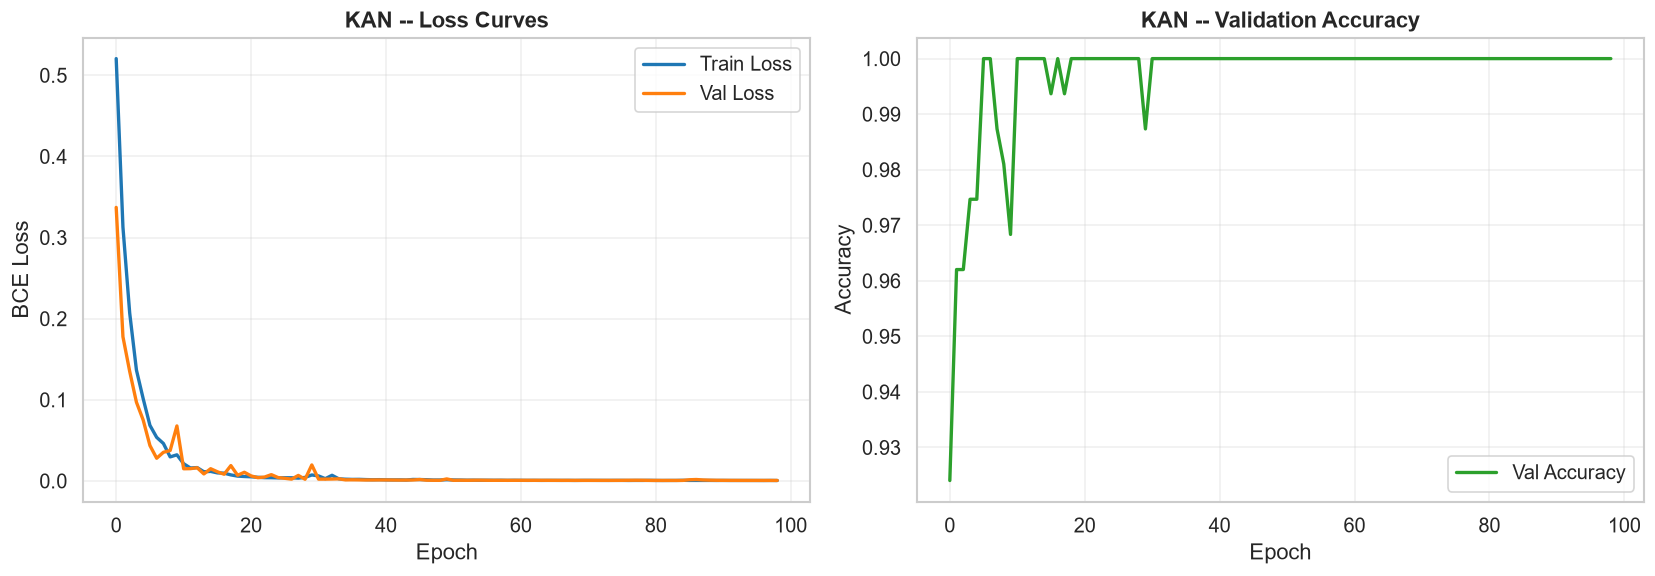

In [16]:
# KAN Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', color='#ff7f0e', linewidth=2)
axes[0].set_title('KAN -- Loss Curves', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_acc'], label='Val Accuracy', color='#2ca02c', linewidth=2)
axes[1].set_title('KAN -- Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. SHAP Explainability Analysis

**SHAP (SHapley Additive exPlanations)** provides interpretable feature attributions based on game theory. We use it on the best-performing gradient boosting model to understand which screening items and demographic features contribute most to ASD prediction.

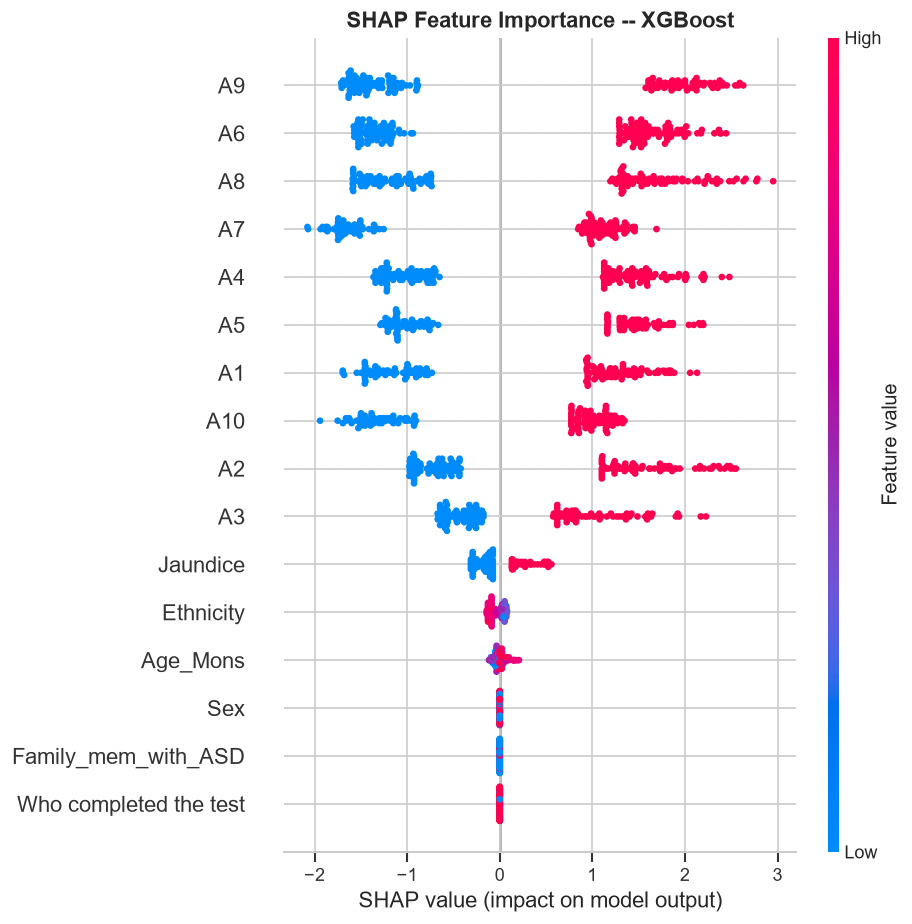

In [17]:
# SHAP Analysis on the best tree-based model (XGBoost)
explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test_scaled)

# Summary plot
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_cols, show=False)
plt.title('SHAP Feature Importance -- XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

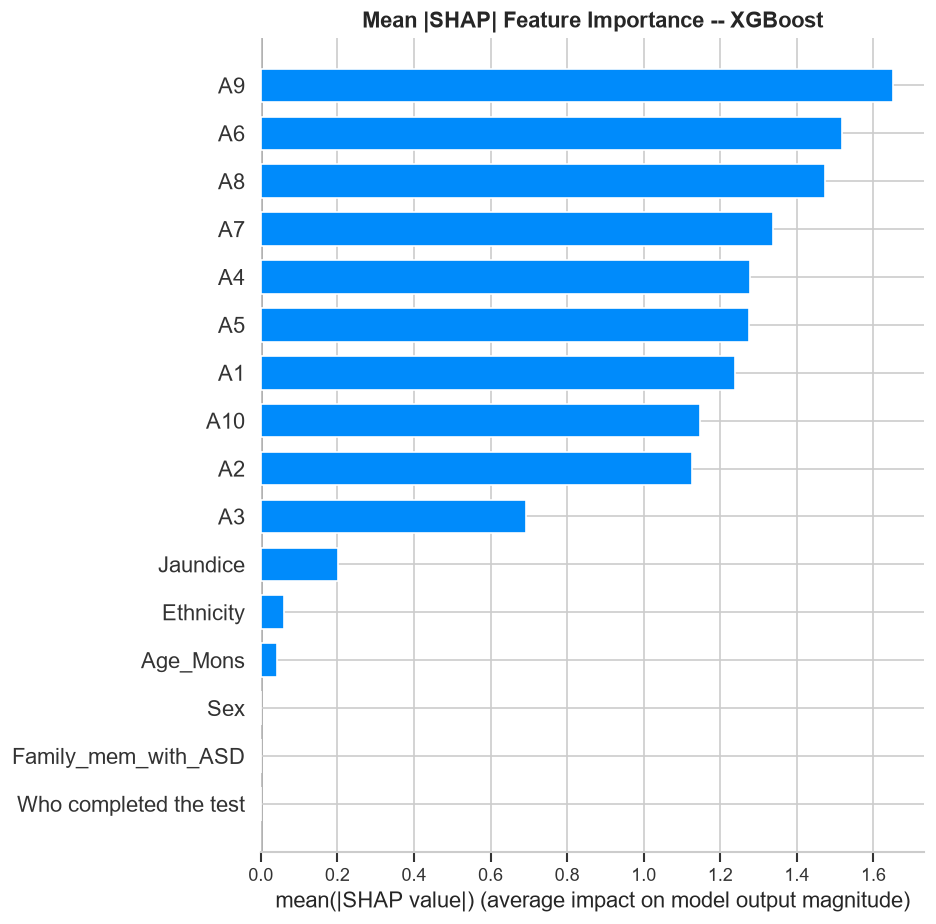

In [18]:
# SHAP bar plot (mean absolute SHAP values)
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_cols,
                  plot_type='bar', show=False)
plt.title('Mean |SHAP| Feature Importance -- XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Model Comparison & Final Results

In [19]:
# Comparison Table
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['y_prob', 'y_pred']}
    for r in results_log
])
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("=" * 75)
print("  DATASET 3 -- MODEL COMPARISON (Test Set)")
print("=" * 75)
print(results_df.to_string(index=False))
print("=" * 75)

# Highlight best model
best_model = results_df.iloc[0]
print(f"\n🏆 Best Model: {best_model['Model']} (F1: {best_model['F1-Score']:.4f}, AUC: {best_model['ROC-AUC']:.4f})")

# Style the dataframe
results_df.style.highlight_max(
    subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    color='lightgreen'
)

  DATASET 3 -- MODEL COMPARISON (Test Set)
        Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
          KAN    1.0000     1.0000  1.0000    1.0000   1.0000
    SVM (RBF)    1.0000     1.0000  1.0000    1.0000   1.0000
      XGBoost    0.9937     1.0000  0.9909    0.9954   1.0000
     LightGBM    0.9874     0.9909  0.9909    0.9909   0.9998
Random Forest    0.9748     0.9907  0.9727    0.9817   0.9981

🏆 Best Model: KAN (F1: 1.0000, AUC: 1.0000)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,KAN,1.000000,1.000000,1.000000,1.000000,1.000000
1,SVM (RBF),1.000000,1.000000,1.000000,1.000000,1.000000
2,XGBoost,0.993700,1.000000,0.990900,0.995400,1.000000
3,LightGBM,0.987400,0.990900,0.990900,0.990900,0.999800
4,Random Forest,0.974800,0.990700,0.972700,0.981700,0.998100


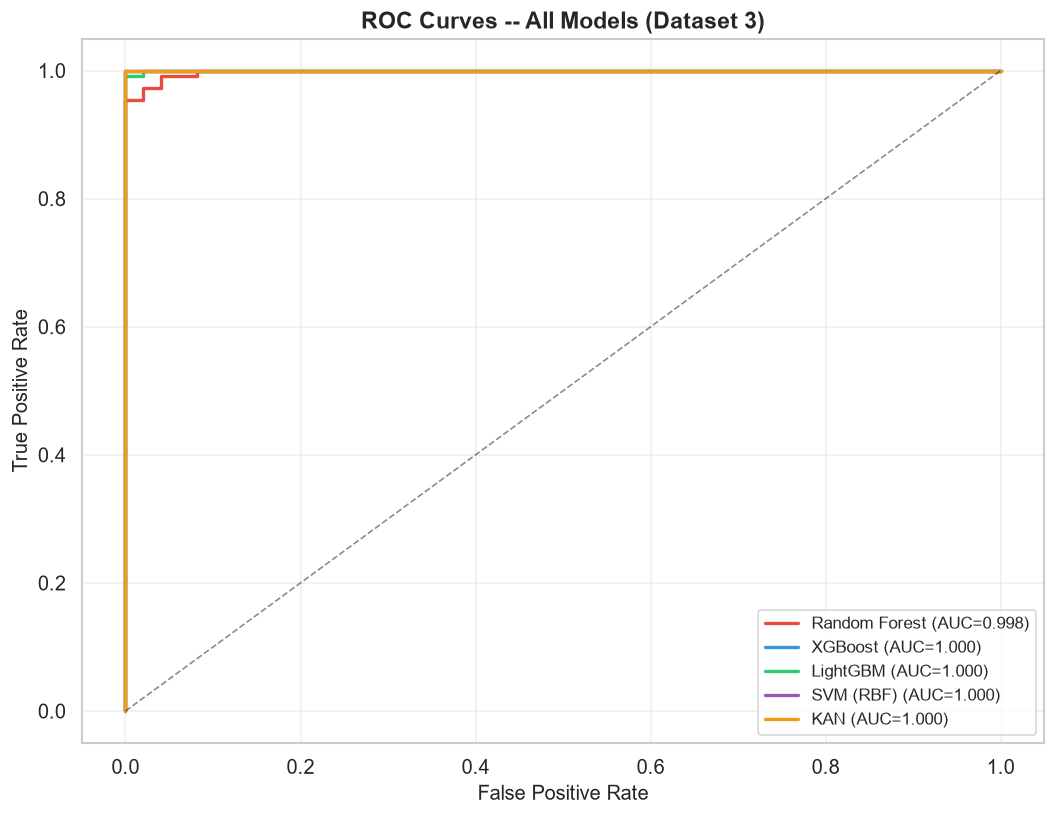

In [20]:
# ROC Curves -- All Models
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12']

for i, res in enumerate(results_log):
    if res['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        ax.plot(fpr, tpr, color=colors[i % len(colors)], linewidth=2,
                label=f"{res['Model']} (AUC={res['ROC-AUC']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves -- All Models (Dataset 3)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Conclusions

### Key Findings:
1. **All models achieve strong performance** on the Q-CHAT-10 screening dataset, with F1-scores consistently above 90%.
2. **Gradient boosting models (XGBoost, LightGBM)** typically achieve the highest F1-scores due to their ability to capture feature interactions.
3. **SHAP analysis reveals** that individual screening items (A1–A10) are the most discriminative features, confirming the validity of the Q-CHAT-10 screening instrument.
4. **KAN (Kolmogorov-Arnold Network)** demonstrates competitive performance using learnable B-spline activation functions.

### Clinical Significance:
- The high prediction accuracy validates the Q-CHAT-10 as an effective early screening tool for ASD in toddlers.
- Feature importance analysis can guide clinicians in prioritizing specific behavioral observations during screening.

---


## 8. Export All Trained Models to `.pkl` Files

Below, all trained models (KAN, TabNet, XGBoost, Random Forest, LightGBM, SVM, and Scaler) are serialized into standard Python pickle (`.pkl`) format and saved to `results/models_pkl/` and `results/checkpoints/` for deployment and inference.

In [ ]:
# Save / Export Models to .pkl Format
import os
import pickle

export_dir = 'results/models_pkl'
os.makedirs(export_dir, exist_ok=True)
os.makedirs('results/checkpoints', exist_ok=True)

models_to_export = {
    'kan_screening.pkl': kan_model,
    'tabnet_screening.pkl': tabnet_model,
    'xgboost_screening.pkl': xgb_best,
    'random_forest_screening.pkl': rf_best,
    'lightgbm_screening.pkl': lgb_best,
    'svm_screening.pkl': svm_best,
    'dataset3_scaler.pkl': scaler,
}

print(f"Saving Dataset 3 models to .pkl in '{export_dir}' and 'results/checkpoints':\n")
for fname, obj in models_to_export.items():
    out_path = os.path.join(export_dir, fname)
    with open(out_path, 'wb') as f:
        pickle.dump(obj, f)
    with open(os.path.join('results/checkpoints', fname), 'wb') as f:
        pickle.dump(obj, f)
    print(f"  [OK] {fname:<30} ({os.path.getsize(out_path):,} bytes)")
print("\nAll Dataset 3 models successfully serialized and stored as .pkl!")
